In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [103]:
df = pd.read_csv("hotel_bookings.csv")


In [104]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(119390, 32)


In [105]:
# df= df.groupby('is_canceled', group_keys=False).apply(
#     lambda x: x.sample(frac=30000/len(df), random_state=42)
# )
# print(df.shape)

In [106]:
df['company'].isna().sum()

np.int64(112593)

In [107]:
def drop_cols_with_many_nans(df, threshold=17000):
    """
    Drop columns that have more than 'threshold' missing values.
    """
    cols_to_drop = df.columns[df.isna().sum() > threshold]
    df_cleaned = df.drop(columns=cols_to_drop , inplace=True)
    return df_cleaned, cols_to_drop

In [108]:
df_cleaned, dropped_cols = drop_cols_with_many_nans(df, threshold=17000)

print("Dropped columns:", dropped_cols)

Dropped columns: Index(['company'], dtype='object')


In [109]:
df.shape

(119390, 31)

In [110]:
print("\nDataset Info:")
print(df.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  m

In [111]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
0                        0                     0       2  ...   
1                  

In [112]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             488
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             16340
days_in_waiting_list   

In [113]:
print("\nStatistical Summary:")
print(df.describe())



Statistical Summary:
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75%                  

In [114]:
df['children'] = df['children'].fillna(df['children'].mode()[0])
df['agent'] = df['agent'].fillna(df['agent'].mode()[0])

# Fill categorical with mode
df['country'] = df['country'].fillna(df['country'].mode()[0])

print("\nMissing Values After Cleaning:\n")
print(df.isnull().sum())


Missing Values After Cleaning:

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                            

In [115]:
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

df = df[df['adr'] >= 0]
df = df[df['lead_time'] >= 0]

In [116]:
df.drop_duplicates(inplace=True)

print("\nShape After Cleaning:")
print(df.shape)


Shape After Cleaning:
(87202, 31)


In [117]:

sns.set_style("whitegrid")

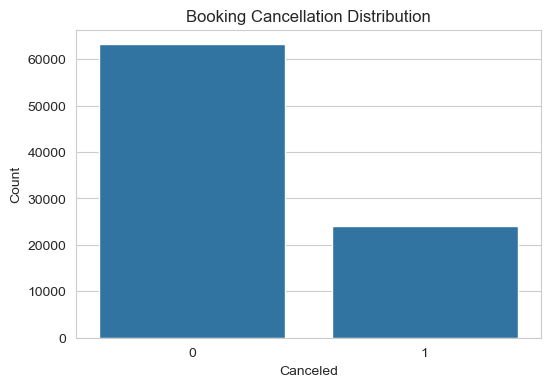

In [118]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=df)
plt.title("Booking Cancellation Distribution")
plt.xlabel("Canceled")
plt.ylabel("Count")
plt.show()

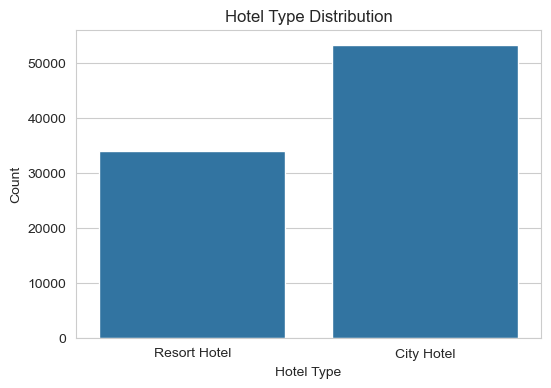

In [119]:
plt.figure(figsize=(6,4))
sns.countplot(x='hotel', data=df)
plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Count")
plt.show()


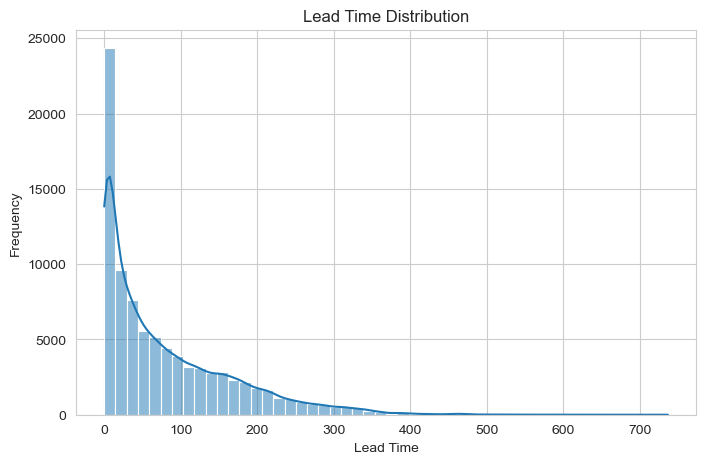

In [120]:
plt.figure(figsize=(8,5))
sns.histplot(df['lead_time'], bins=50, kde=True)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.ylabel("Frequency")
plt.show()


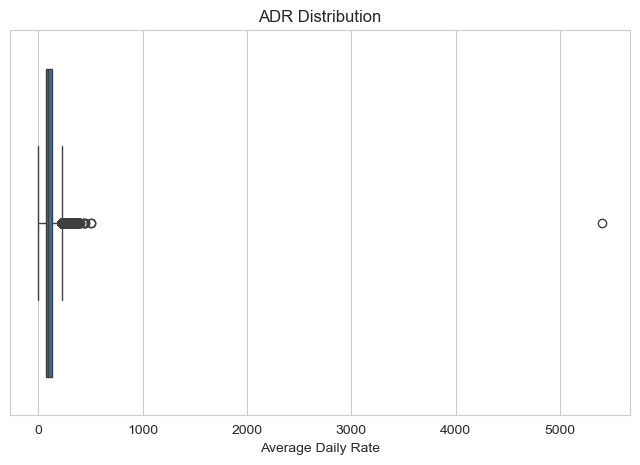

In [121]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['adr'])
plt.title("ADR Distribution")
plt.xlabel("Average Daily Rate")
plt.show()

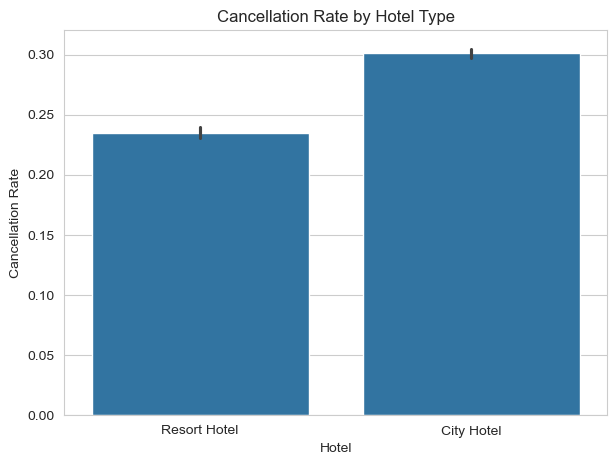

In [122]:
plt.figure(figsize=(7,5))
sns.barplot(x='hotel', y='is_canceled', data=df)
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel")
plt.ylabel("Cancellation Rate")
plt.show()

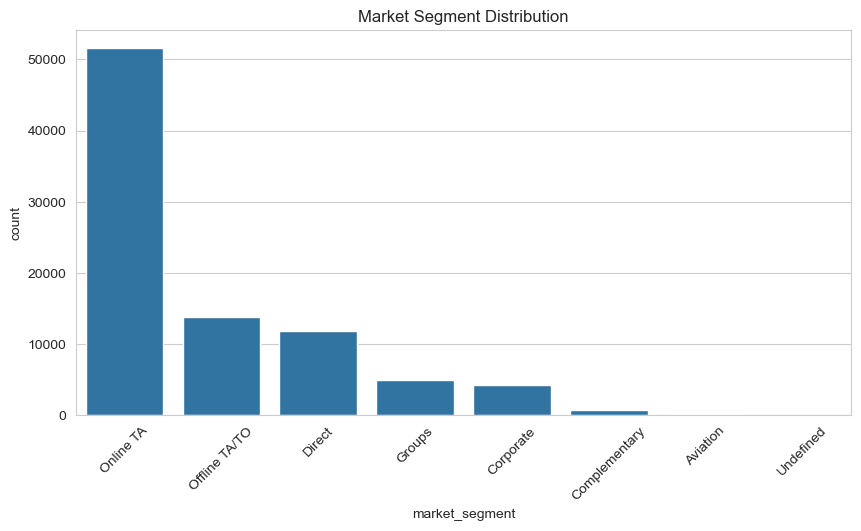

In [123]:
plt.figure(figsize=(10,5))
sns.countplot(x='market_segment', data=df,
              order=df['market_segment'].value_counts().index)
plt.title("Market Segment Distribution")
plt.xticks(rotation=45)
plt.show()

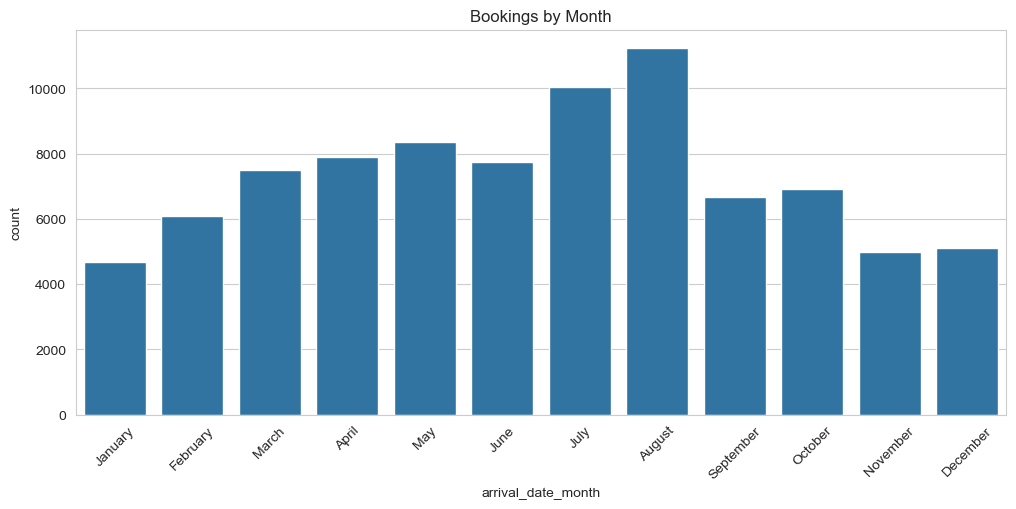

In [124]:
plt.figure(figsize=(12,5))
sns.countplot(
    x='arrival_date_month',
    data=df,
    order=[
        'January','February','March','April',
        'May','June','July','August',
        'September','October','November','December'
    ]
)
plt.title("Bookings by Month")
plt.xticks(rotation=45)
plt.show()

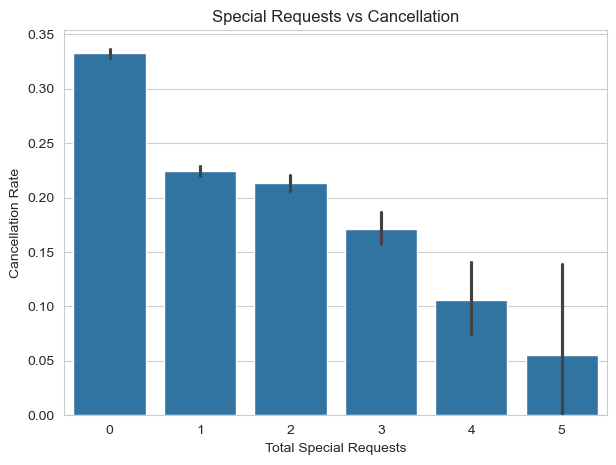

In [125]:
plt.figure(figsize=(7,5))
sns.barplot(x='total_of_special_requests',
            y='is_canceled',
            data=df)

plt.title("Special Requests vs Cancellation")
plt.xlabel("Total Special Requests")
plt.ylabel("Cancellation Rate")
plt.show()

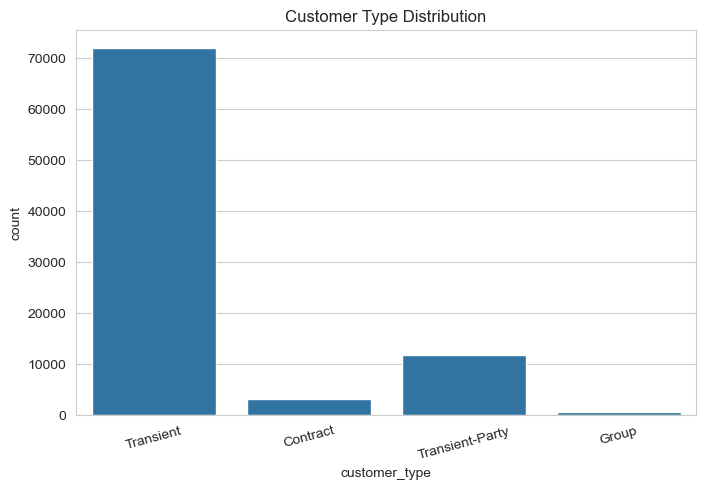

In [126]:
plt.figure(figsize=(8,5))
sns.countplot(x='customer_type', data=df)
plt.title("Customer Type Distribution")
plt.xticks(rotation=15)
plt.show()


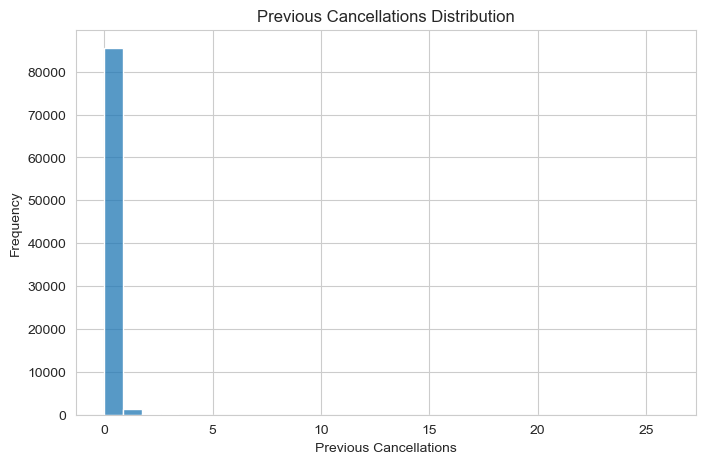

In [127]:
plt.figure(figsize=(8,5))
sns.histplot(df['previous_cancellations'], bins=30)
plt.title("Previous Cancellations Distribution")
plt.xlabel("Previous Cancellations")
plt.ylabel("Frequency")
plt.show()

In [128]:
y = df['is_canceled']
X = df.drop('is_canceled', axis=1)

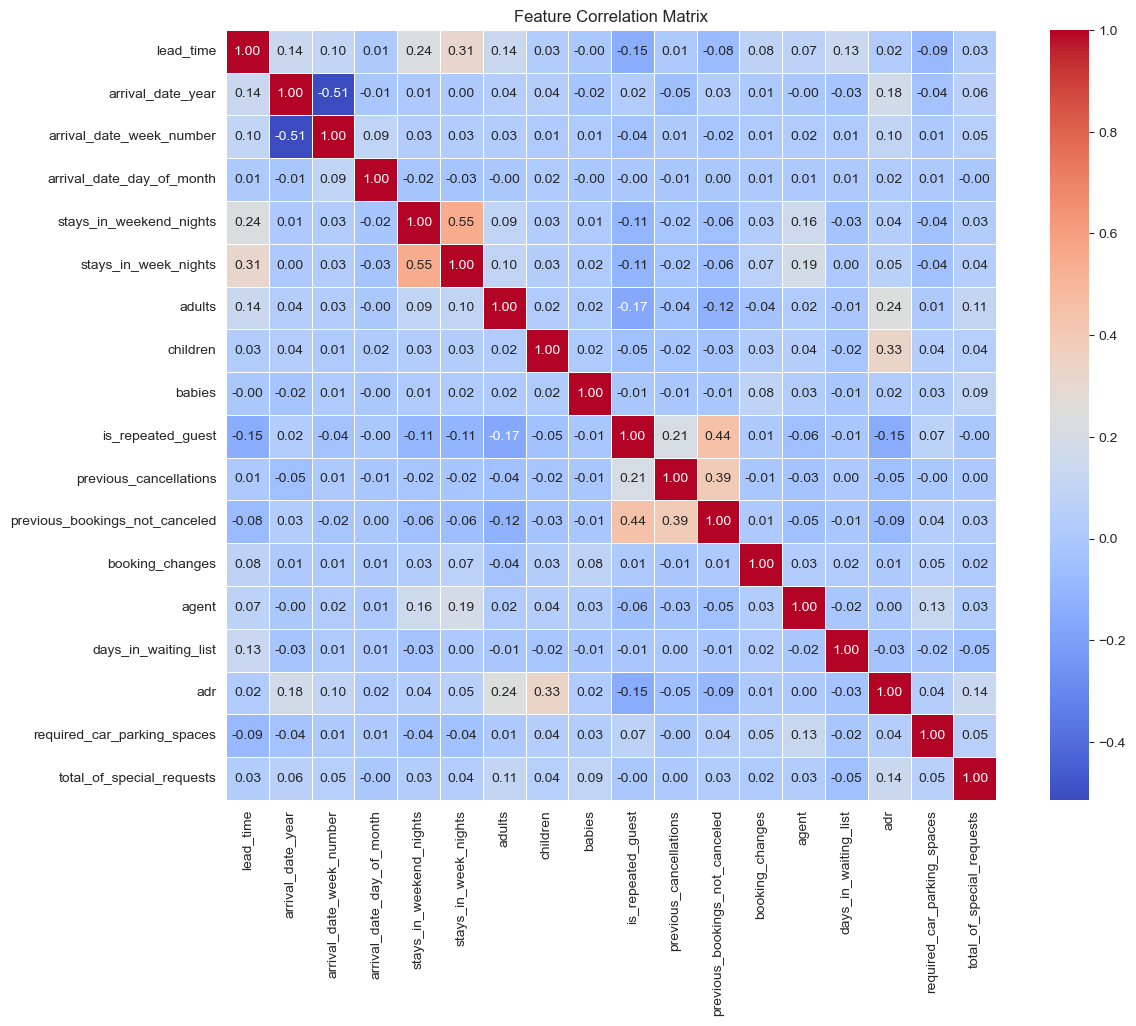

In [129]:
num_cols = X.select_dtypes(include=np.number).columns

plt.figure(figsize=(14, 10))
corr = X[num_cols].corr()
sns.heatmap(
    corr,
    annot=True,       
    fmt=".2f",         
    cmap="coolwarm",   
    linewidths=0.5,    
    square=True        
)

plt.title("Feature Correlation Matrix")
plt.show()

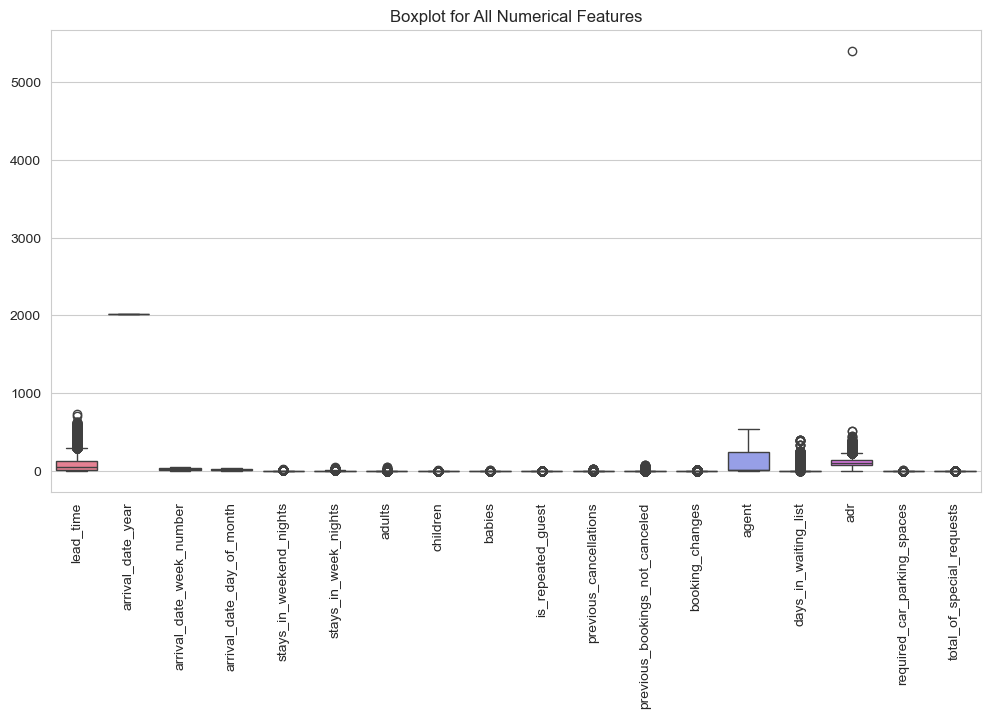

In [130]:

num_cols = X.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=X[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot for All Numerical Features")
plt.show()

In [131]:

# ==========================
# DETECT OUTLIERS (CHECK FIRST)
# ==========================

def detect_outliers_iqr(data, cols):
    """Detect outliers using IQR method"""
    outliers_count = 0
    outlier_cols = []
    
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        col_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        if col_outliers > 0:
            outliers_count += col_outliers
            outlier_cols.append((col, col_outliers))
    
    return outliers_count, outlier_cols

# Check for outliers
outliers_count, outlier_cols = detect_outliers_iqr(X, num_cols)

print(f"Total outliers found: {outliers_count}")
if outlier_cols:
    print("\nOutliers per column:")
    for col, count in outlier_cols:
        print(f"  {col}: {count} outliers")
else:
    print("No outliers detected!")

# ==========================
# IQR function - Apply ONLY if outliers exist
# ==========================

if outliers_count > 0:
    print("\n✓ Applying outlier removal method...")
    
    def remove_outliers_iqr(data, cols):
        for col in cols:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            data[col] = np.clip(data[col], lower, upper)

        return data

    # Apply outlier removal
    X = remove_outliers_iqr(X, num_cols)
    print(f"After removing outliers: {X.shape}")
else:
    print("\n✗ No outliers to remove - keeping data as is")


Total outliers found: 73835

Outliers per column:
  lead_time: 2394 outliers
  stays_in_weekend_nights: 213 outliers
  stays_in_week_nights: 1514 outliers
  adults: 22716 outliers
  children: 8364 outliers
  babies: 914 outliers
  is_repeated_guest: 3363 outliers
  previous_cancellations: 1681 outliers
  previous_bookings_not_canceled: 3537 outliers
  booking_changes: 15803 outliers
  days_in_waiting_list: 855 outliers
  adr: 2506 outliers
  required_car_parking_spaces: 7306 outliers
  total_of_special_requests: 2669 outliers

✓ Applying outlier removal method...
After removing outliers: (87202, 30)


In [132]:
print("\nFinal Missing Values:\n")
print(X.isnull().sum())

print("\nFinal Dataset Shape:", X.shape)


Final Missing Values:

hotel                             0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
tota

In [133]:
target_col = y.name

df_balanced = pd.concat([X, y], axis=1)

class_0 = df_balanced[df_balanced[target_col] == 0]
class_1 = df_balanced[df_balanced[target_col] == 1]

# Under-sample majority
class_0_under = class_0.sample(len(class_1), random_state=42)

# Over-sample minority
class_1_over = class_1.sample(len(class_0_under), replace=True, random_state=42)

# Combine
df_balanced = pd.concat([class_0_under, class_1_over])

# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42)

# Split again
X = df_balanced.drop(columns=[target_col])
y = df_balanced[target_col]

print("After balancing:")
print(y.value_counts())

After balancing:
is_canceled
0    24008
1    24008
Name: count, dtype: int64


In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (38412, 30)
Test shape: (9604, 30)


In [135]:

num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

In [136]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [137]:
svd = TruncatedSVD(random_state=42)
svm = SVC()


In [138]:
pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('svd', svd),
    ('svm', svm)
])

param_grid = {
    "svd__n_components": [5, 10, 20, 50],

    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.01],
    "svm__kernel": ["rbf"]
}

In [139]:

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [140]:
grid.fit(X_train, y_train)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_...
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date'],
      dtype='object'))])),
                                       ('svd', TruncatedSVD(random_state=42)),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svd__n_components': [5, 10, 20, 50],
                         'svm__C': [0.1, 1, 10], 'svm__gamma': ['scale', 0.01],
                         'svm__kernel': ['rbf']},
             scoring='accuracy', verbose=2)

In [141]:
best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)


Best Parameters:
{'svd__n_components': 20, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


In [142]:
y_pred = best_model.predict(X_test)


In [149]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(grid.best_estimator_, X, y, cv=5)

print(scores)
print("Mean:", scores.mean())

[1. 1. 1. 1. 1.]
Mean: 1.0


In [150]:
import numpy as np

y_random = np.random.permutation(y)

scores = cross_val_score(grid.best_estimator_, X, y_random, cv=5)

print(scores)
print("Mean:", scores.mean())

[0.49906289 0.4998438  0.50192648 0.49369989 0.49859419]
Mean: 0.4986254490702809


In [151]:
top_features = df.corr(numeric_only=True)['is_canceled'].sort_values(ascending=False)

print("Top positive correlations:\n", top_features.head(10))
print("\nTop negative correlations:\n", top_features.tail(10))

Top positive correlations:
 is_canceled                  1.000000
lead_time                    0.184405
adr                          0.127191
arrival_date_year            0.088031
stays_in_week_nights         0.084061
adults                       0.080133
children                     0.067135
stays_in_weekend_nights      0.060890
previous_cancellations       0.051490
arrival_date_day_of_month    0.005414
Name: is_canceled, dtype: float64

Top negative correlations:
 arrival_date_day_of_month         0.005414
days_in_waiting_list              0.004698
arrival_date_week_number          0.001639
agent                            -0.004957
babies                           -0.020645
previous_bookings_not_canceled   -0.052192
is_repeated_guest                -0.088781
booking_changes                  -0.093284
total_of_special_requests        -0.120849
required_car_parking_spaces      -0.184524
Name: is_canceled, dtype: float64


In [143]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4827
           1       1.00      1.00      1.00      4777

    accuracy                           1.00      9604
   macro avg       1.00      1.00      1.00      9604
weighted avg       1.00      1.00      1.00      9604


Confusion Matrix:
[[4827    0]
 [   0 4777]]


In [144]:
# predictions
y_train_pred = grid.predict(X_train)
y_test_pred = grid.predict(X_test)

# accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 1.0


In [145]:
import joblib

joblib.dump(best_model, "hotel_model.pkl")



['hotel_model.pkl']

In [146]:
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']

In [147]:
joblib.dump(X.columns, "columns.pkl")
joblib.dump(grid.best_estimator_, "model.pkl")
joblib.dump(X.dtypes, "dtypes.pkl")

['dtypes.pkl']

In [148]:
print("Model saved successfully!")

Model saved successfully!
